In [1]:
# Cube Alchemy AdventureWorks Demo
import pandas as pd
from cube_alchemy import Hypercube
import matplotlib.pyplot as plt

from pathlib import Path

current_dir = Path.cwd()
#print(f"Current working directory: {current_dir}")

In [2]:
from tables import tables
print(tables.keys())

dict_keys(['accounts', 'actuals', 'budget', 'business_unit_dim', 'calendar_dim', 'cost_center_dim', 'location_dim', 'pnl_report_mapping', 'project_dim', 'vendor_dim'])


In [3]:
# rename amount columns in all tables to "amount (table_name)"
for table_name, df in tables.items():
    if 'amount' in df.columns:
        df.rename(columns={'amount': f'amount ({table_name})'}, inplace=True)
    # if 'account_number' convert into a int and then into a str
    if 'account_number' in df.columns:
        df['account_number'] = df['account_number'].astype(int).astype(str)


Hypercube initialization failed due to cyclic relationships or other issues.


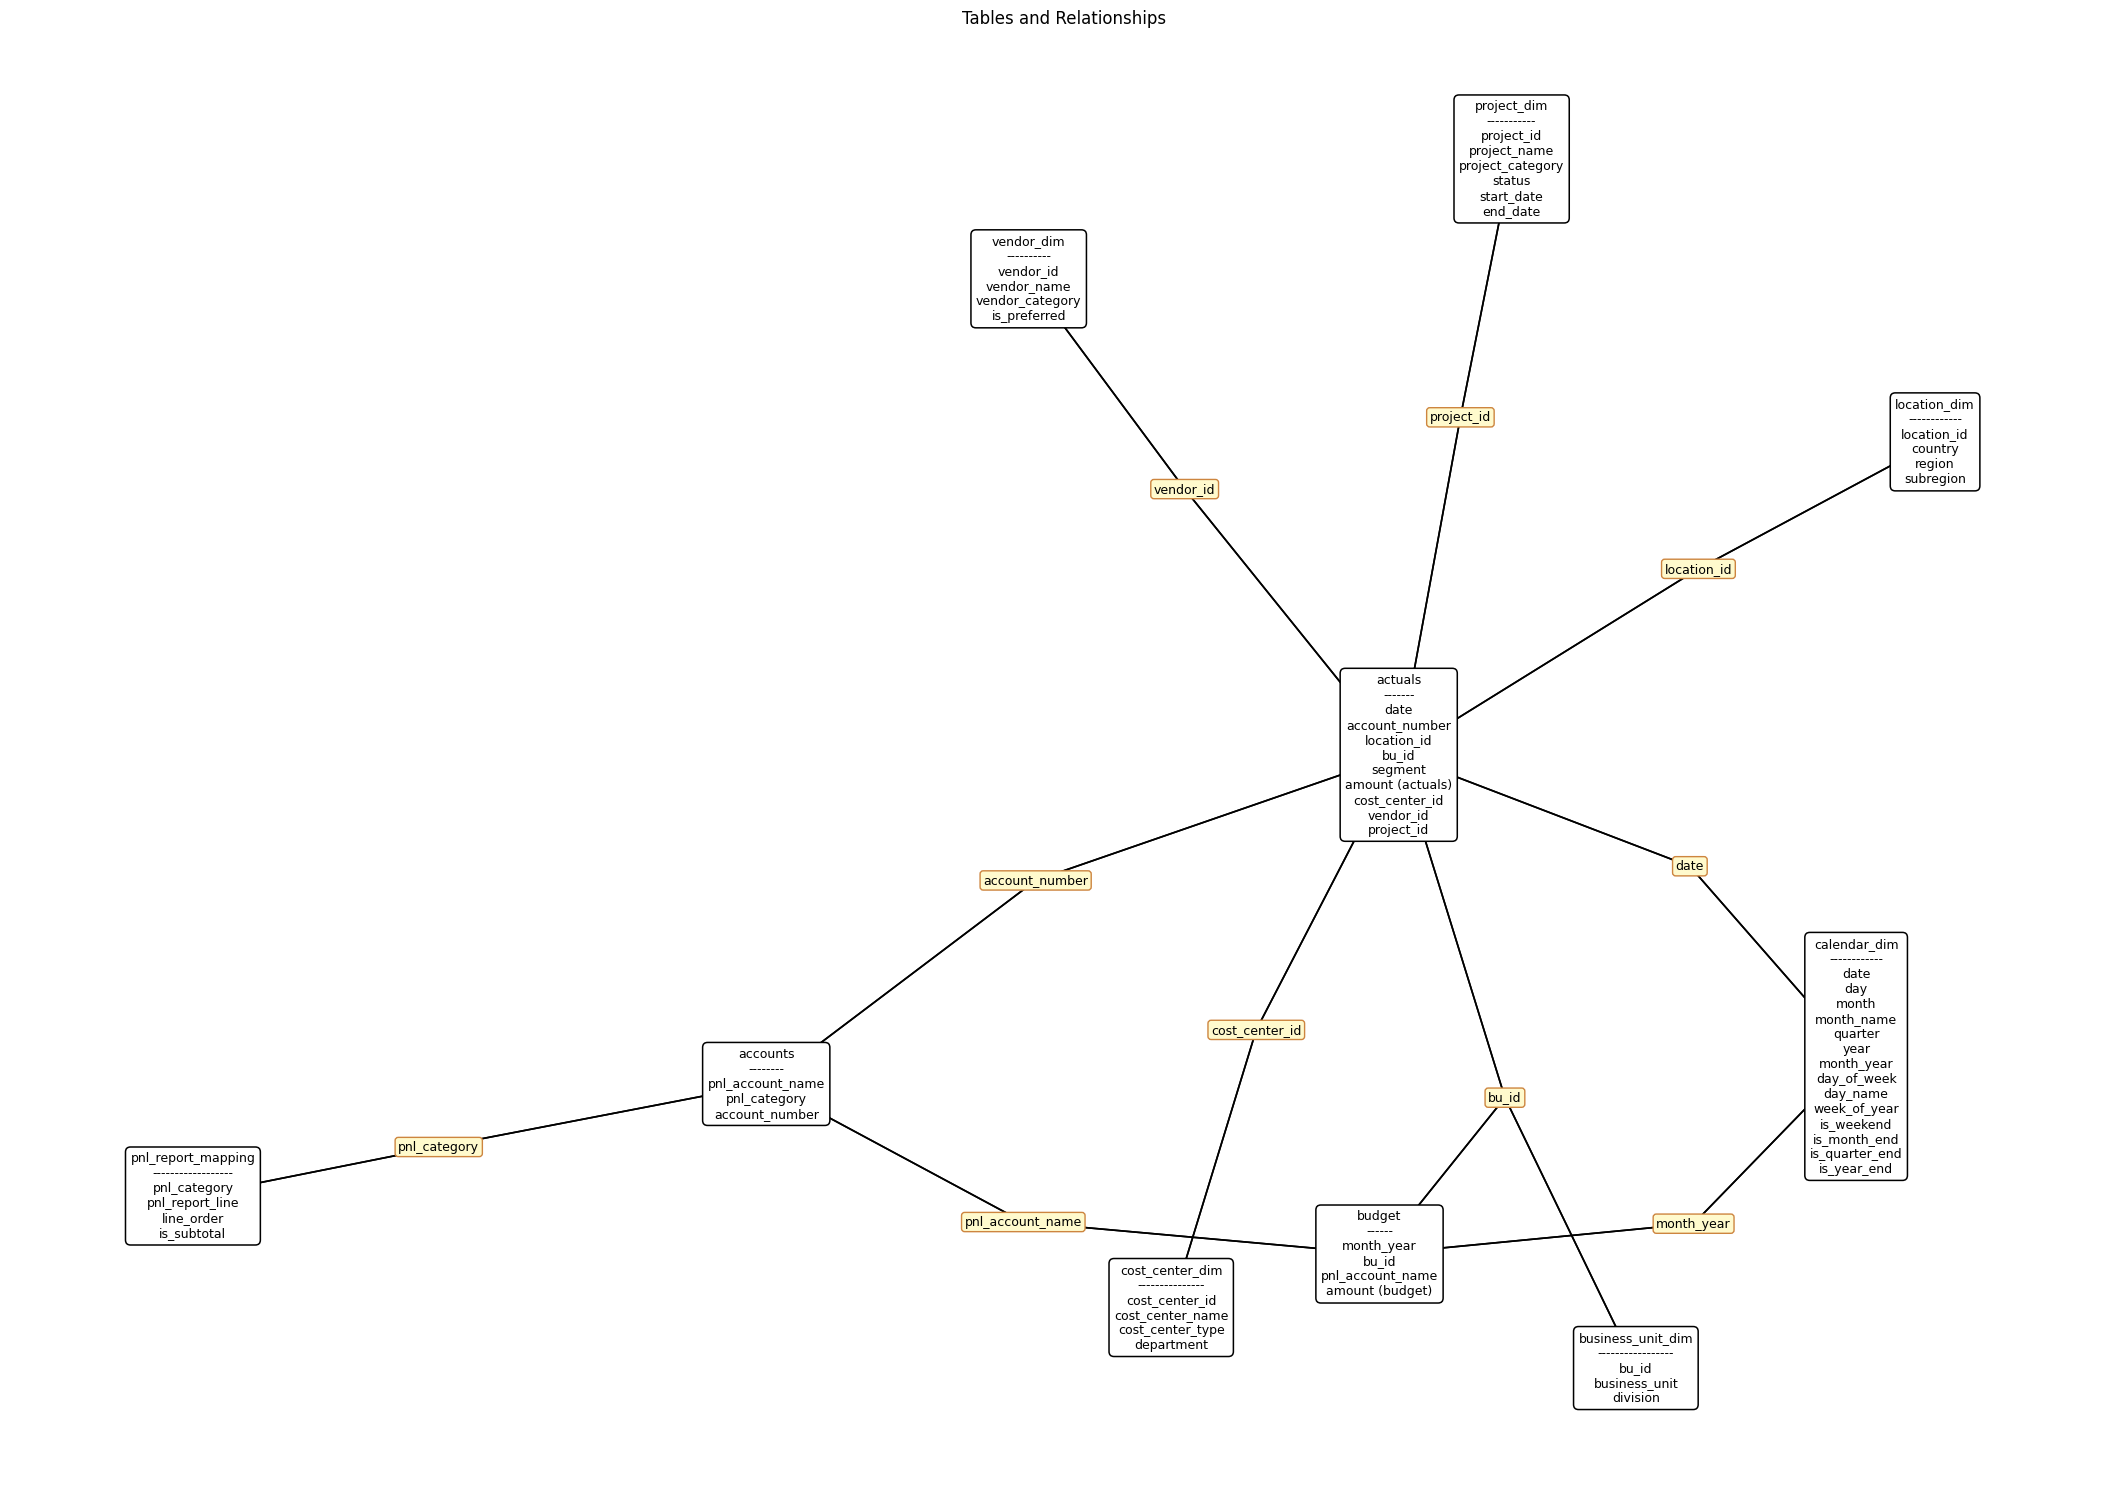

Cyclic relationships detected in the hypercube: budget -> actuals -> accounts
DataModel initialization failed: Cyclic relationships detected in the hypercube


Error creating Hypercube: Cyclic relationships detected in the hypercube


In [4]:
import copy
tables_working = copy.deepcopy(tables)
try:
    cube = Hypercube(tables_working, False)
except Exception as e:
    print("Error creating Hypercube:", e)

In [5]:
## We need to fix the circular references

actuals_prep = pd.merge(
    tables_working['actuals'][['date', 'account_number', 'bu_id']].drop_duplicates(),
    tables_working['calendar_dim'][['date', 'month_year']],
    on='date',
    how='left'
)

# Add pnl_account_name to actuals for linking with budget
actuals_dims = pd.merge(
    actuals_prep,
    tables_working['accounts'][['account_number', 'pnl_account_name']].drop_duplicates(),
    on='account_number',
    how='left'
).drop_duplicates()

# Step 2.2: Prepare budget dimension data
budget_dims = tables_working['budget'][['month_year', 'pnl_account_name', 'bu_id']].drop_duplicates()
# create a date as first date of the month for budget to connect to the calendar
budget_dims['date'] = budget_dims['month_year'].apply(lambda x: pd.to_datetime(x + '-01')).dt.date

#just in case...
actuals_dims['date'] = pd.to_datetime(actuals_dims['date']).dt.date
tables_working['calendar_dim']['date'] = pd.to_datetime(tables_working['calendar_dim']['date']).dt.date
# Step 2.3: Create the initial fact_link table with all distinct dimensions
# This creates one row for each unique combination of dimension values
fact_link_dims = pd.DataFrame()

# Add all distinct dimension values from actuals
fact_link_dims = pd.concat([
    fact_link_dims,
    actuals_dims
])

# Add all distinct dimension values from budget
fact_link_dims = pd.concat([
    fact_link_dims,
    budget_dims
])

# Remove duplicates to get unique combinations
fact_link_dims = fact_link_dims.drop_duplicates().reset_index(drop=True)

def create_composite_key(df, key_columns:list):
    column_name = ' | '.join(key_columns) + ' (key)'
    #I want to create a key by concatenating the values of the key columns
    df[column_name] = df[key_columns].astype(str).agg(' | '.join, axis=1)
    return df[column_name]


# Now create the keys with consistent data types
create_composite_key(fact_link_dims, ['date', 'account_number', 'bu_id'])

create_composite_key(fact_link_dims, ['month_year', 'pnl_account_name', 'bu_id'])

create_composite_key(tables_working['actuals'], ['date', 'account_number', 'bu_id'])

create_composite_key(tables_working['budget'], ['month_year', 'pnl_account_name', 'bu_id'])

fact_link_dims.drop(columns=['month_year'], inplace=True)
fact_link_dims

,date,account_number,bu_id,pnl_account_name,date | account_number | bu_id (key),month_year | pnl_account_name | bu_id (key)
0,2023-01-02,1101,7,Sales Returns,2023-01-02 | 1101 | 7,2023-01 | Sales Returns | 7
1,2023-01-02,1202,8,Net Revenue,2023-01-02 | 1202 | 8,2023-01 | Net Revenue | 8
2,2023-01-02,1203,1,Net Revenue,2023-01-02 | 1203 | 1,2023-01 | Net Revenue | 1
3,2023-01-02,2003,7,Direct Materials,2023-01-02 | 2003 | 7,2023-01 | Direct Materials | 7
4,2023-01-02,2103,4,Direct Labor,2023-01-02 | 2103 | 4,2023-01 | Direct Labor | 4
...,...,...,...,...,...,...
5329,2023-12-01,NaN,8,Rent,2023-12-01 | nan | 8,2023-12 | Rent | 8
5330,2023-12-01,NaN,8,Sales Commissions,2023-12-01 | nan | 8,2023-12 | Sales Commissions | 8
5331,2023-12-01,NaN,8,Sales Returns,2023-12-01 | nan | 8,2023-12 | Sales Returns | 8
5332,2023-12-01,NaN,8,Taxes,2023-12-01 | nan | 8,2023-12 | Taxes | 8


In [6]:
#remove columns from original actual and budget tables
tables_working['actuals'] = tables_working['actuals'].drop(columns=['date', 'account_number', 'bu_id'])
tables_working['budget'] = tables_working['budget'].drop(columns=['month_year', 'pnl_account_name', 'bu_id'])

In [7]:
tables_working['Link_Actuals_Budget'] = fact_link_dims

In [8]:
# store all tables into csv
if False:
    current_dir = Path.cwd()
    for table_name, df in tables_working.items():
        df.to_csv(current_dir / f"output/{table_name}.csv", index=False)


In [9]:
cube = Hypercube(tables_working,False)

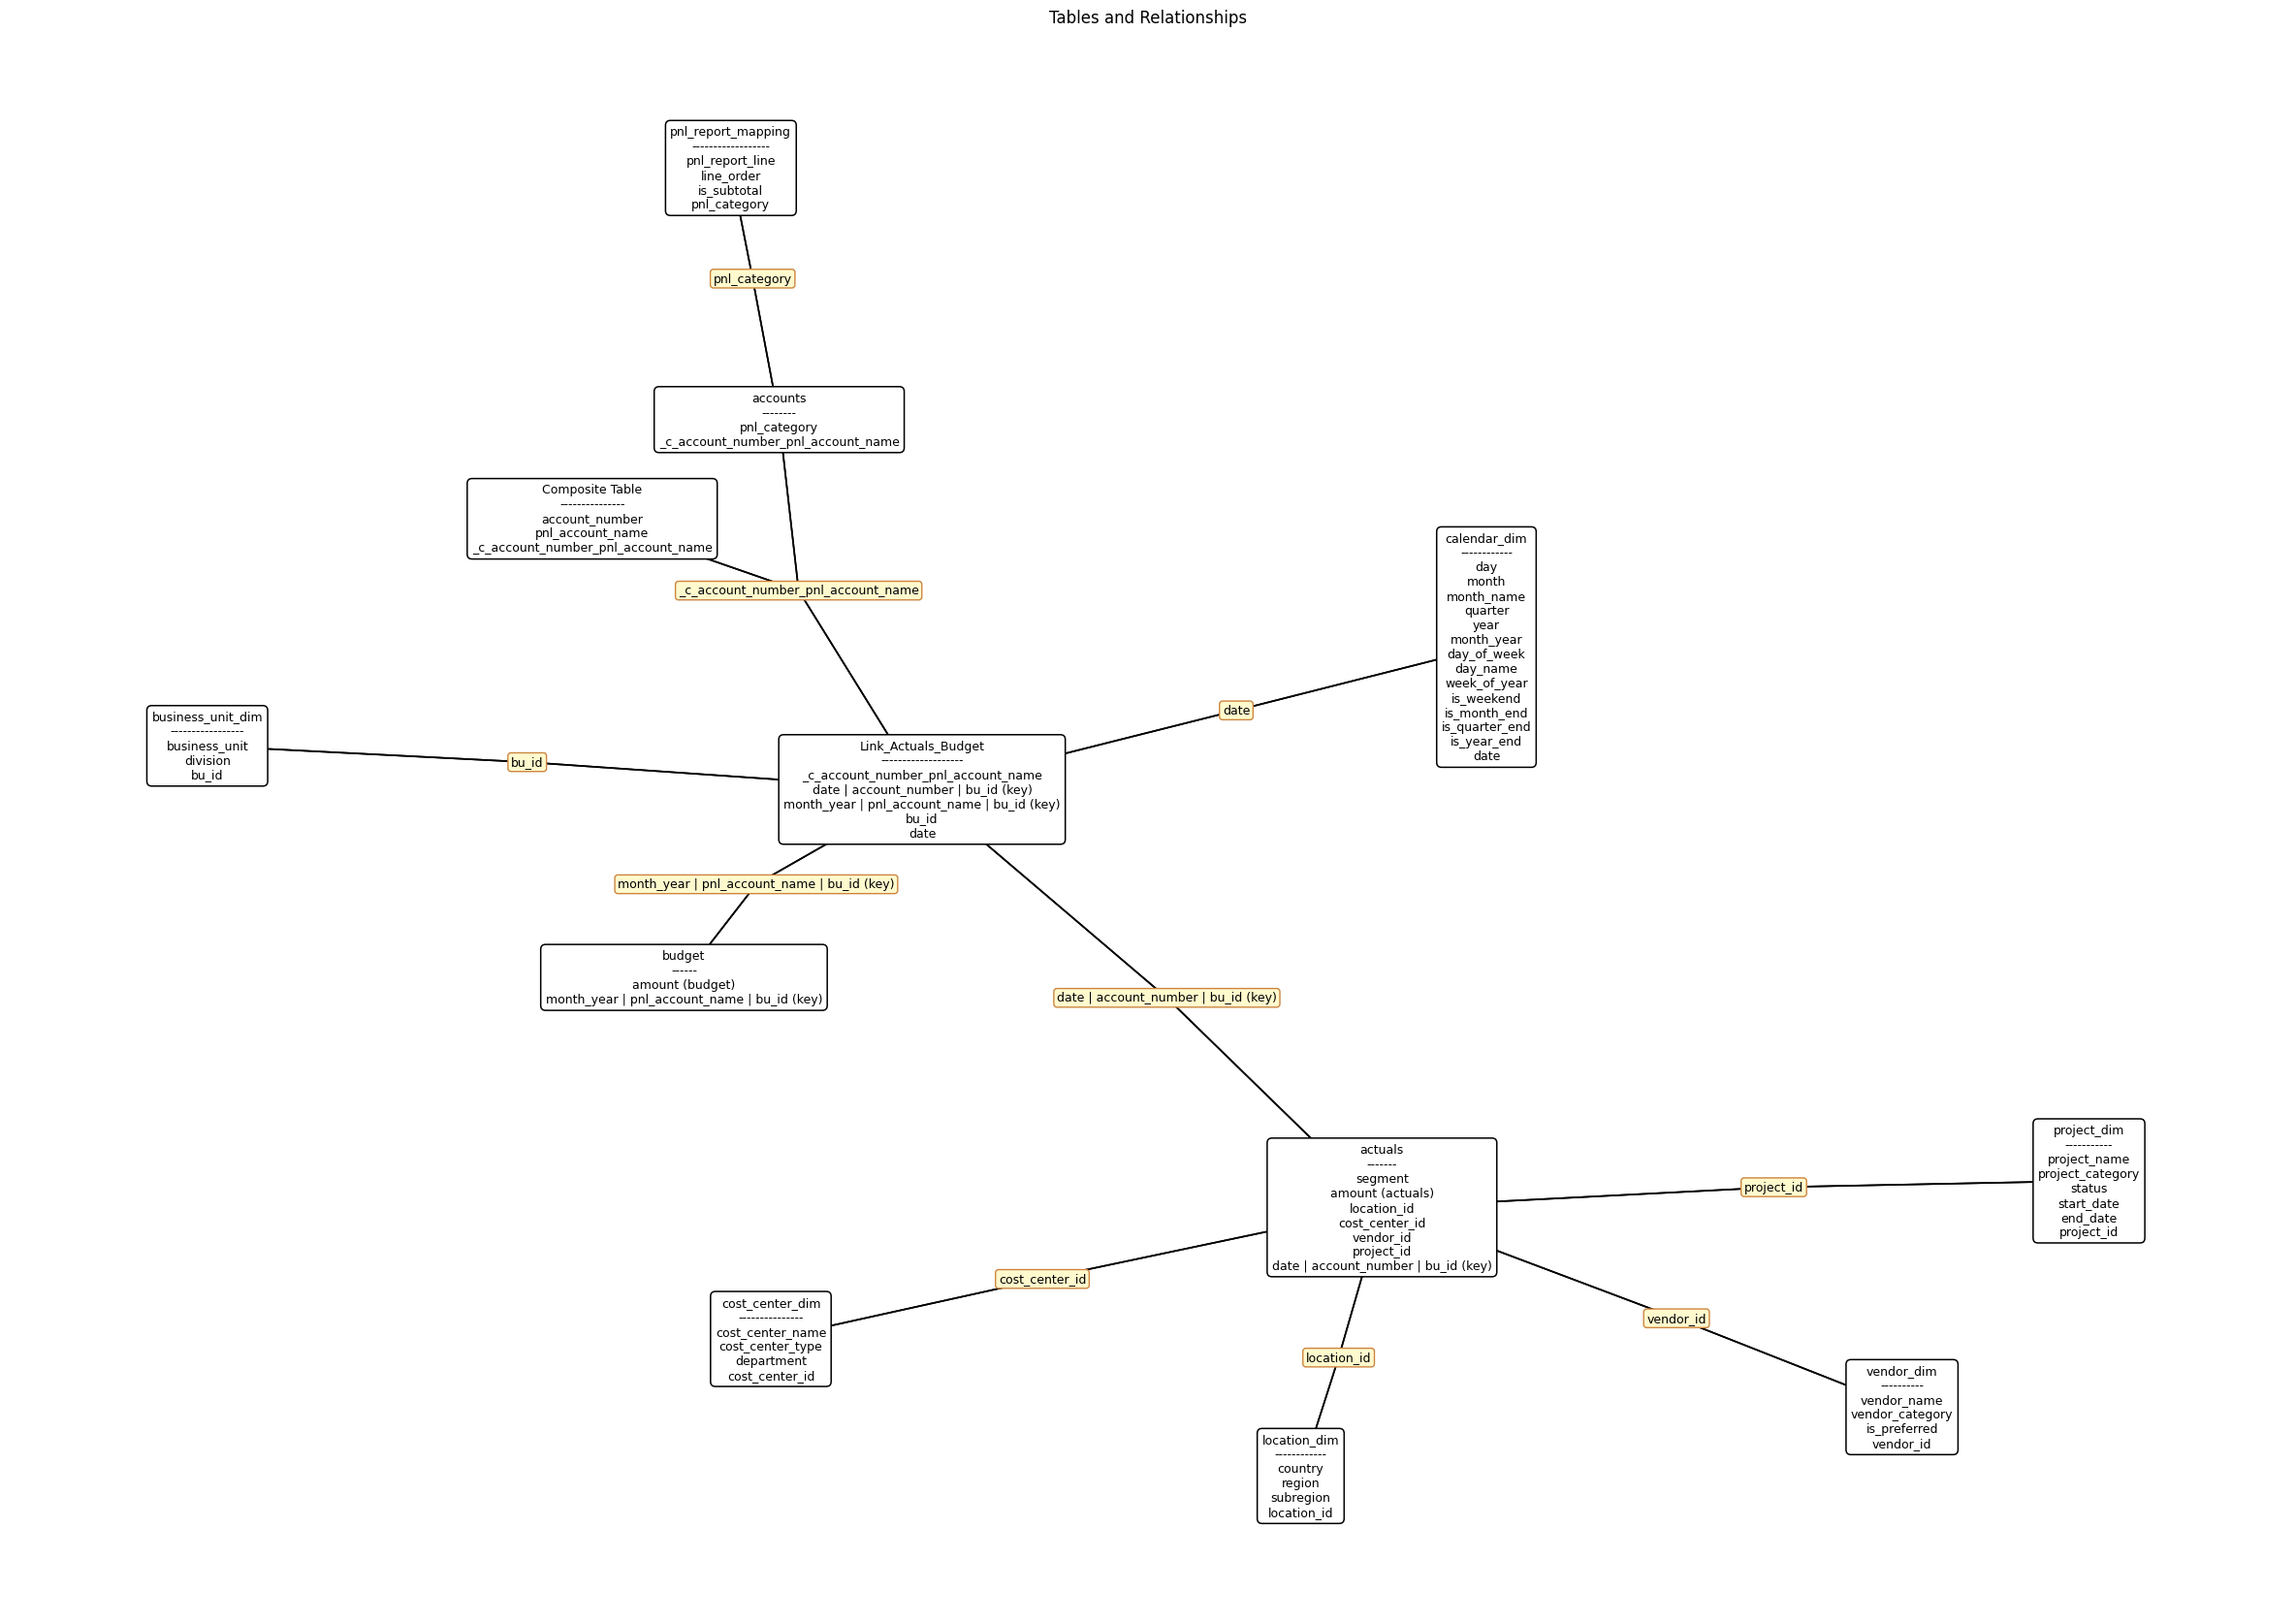

In [10]:
cube.visualize_graph(seed=21,full_column_names=False)

In [11]:
cube.relationship_matrix()

,location_id,project_id,bu_id,pnl_category,month_year | pnl_account_name | bu_id (key),account_number,pnl_account_name,date,date | account_number | bu_id (key),cost_center_id,vendor_id
0,NaN,NaN,1.0,NaN,2023-01 | Direct Labor | 1,NaN,Direct Labor,2023-01-01,2023-01-01 | nan | 1,NaN,NaN
1,NaN,NaN,1.0,NaN,2023-01 | Direct Materials | 1,NaN,Direct Materials,2023-01-01,2023-01-01 | nan | 1,NaN,NaN
2,NaN,NaN,1.0,NaN,2023-01 | Gross Revenue | 1,NaN,Gross Revenue,2023-01-01,2023-01-01 | nan | 1,NaN,NaN
3,NaN,NaN,1.0,NaN,2023-01 | Interest | 1,NaN,Interest,2023-01-01,2023-01-01 | nan | 1,NaN,NaN
4,NaN,NaN,1.0,NaN,2023-01 | Manufacturing Overhead | 1,NaN,Manufacturing Overhead,2023-01-01,2023-01-01 | nan | 1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
5406,11.0,NaN,8.0,COGS,2023-12 | Direct Labor | 8,2104,Direct Labor,2023-12-29,2023-12-29 | 2104 | 8,11.0,NaN
5407,12.0,NaN,8.0,Operating Expenses,2023-12 | Sales Commissions | 8,3201,Sales Commissions,2023-12-29,2023-12-29 | 3201 | 8,7.0,NaN
5408,1.0,NaN,8.0,Revenue,2023-12 | Sales Returns | 8,1101,Sales Returns,2023-12-29,2023-12-29 | 1101 | 8,2.0,NaN
5409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-30,NaN,NaN,NaN


In [12]:
cube.build_table_cardinalities()

,table1,table2,shared_column,cardinality,keys_in_t1,keys_in_t2,keys_in_both,max_rows_per_key_t1,max_rows_per_key_t2
0,accounts,pnl_report_mapping,pnl_category,many-to-many,5,5,5,20,6
1,accounts,Link_Actuals_Budget,_composite_key_account_number_pnl_account_name,one-to-many,48,66,48,1,177
2,accounts,Composite Table,_composite_key_account_number_pnl_account_name,one-to-one,48,66,48,1,1
3,Link_Actuals_Budget,Composite Table,_composite_key_account_number_pnl_account_name,many-to-one,66,66,66,177,1
4,actuals,Link_Actuals_Budget,date | account_number | bu_id (key),many-to-one,3882,3978,3882,2,1
5,budget,Link_Actuals_Budget,month_year | pnl_account_name | bu_id (key),one-to-many,1452,1452,1452,1,13
6,business_unit_dim,Link_Actuals_Budget,bu_id,one-to-many,8,8,8,1,729
7,calendar_dim,Link_Actuals_Budget,date,one-to-many,365,293,293,1,146
8,actuals,location_dim,location_id,many-to-one,12,12,12,355,1
9,actuals,cost_center_dim,cost_center_id,many-to-one,13,12,12,291,1


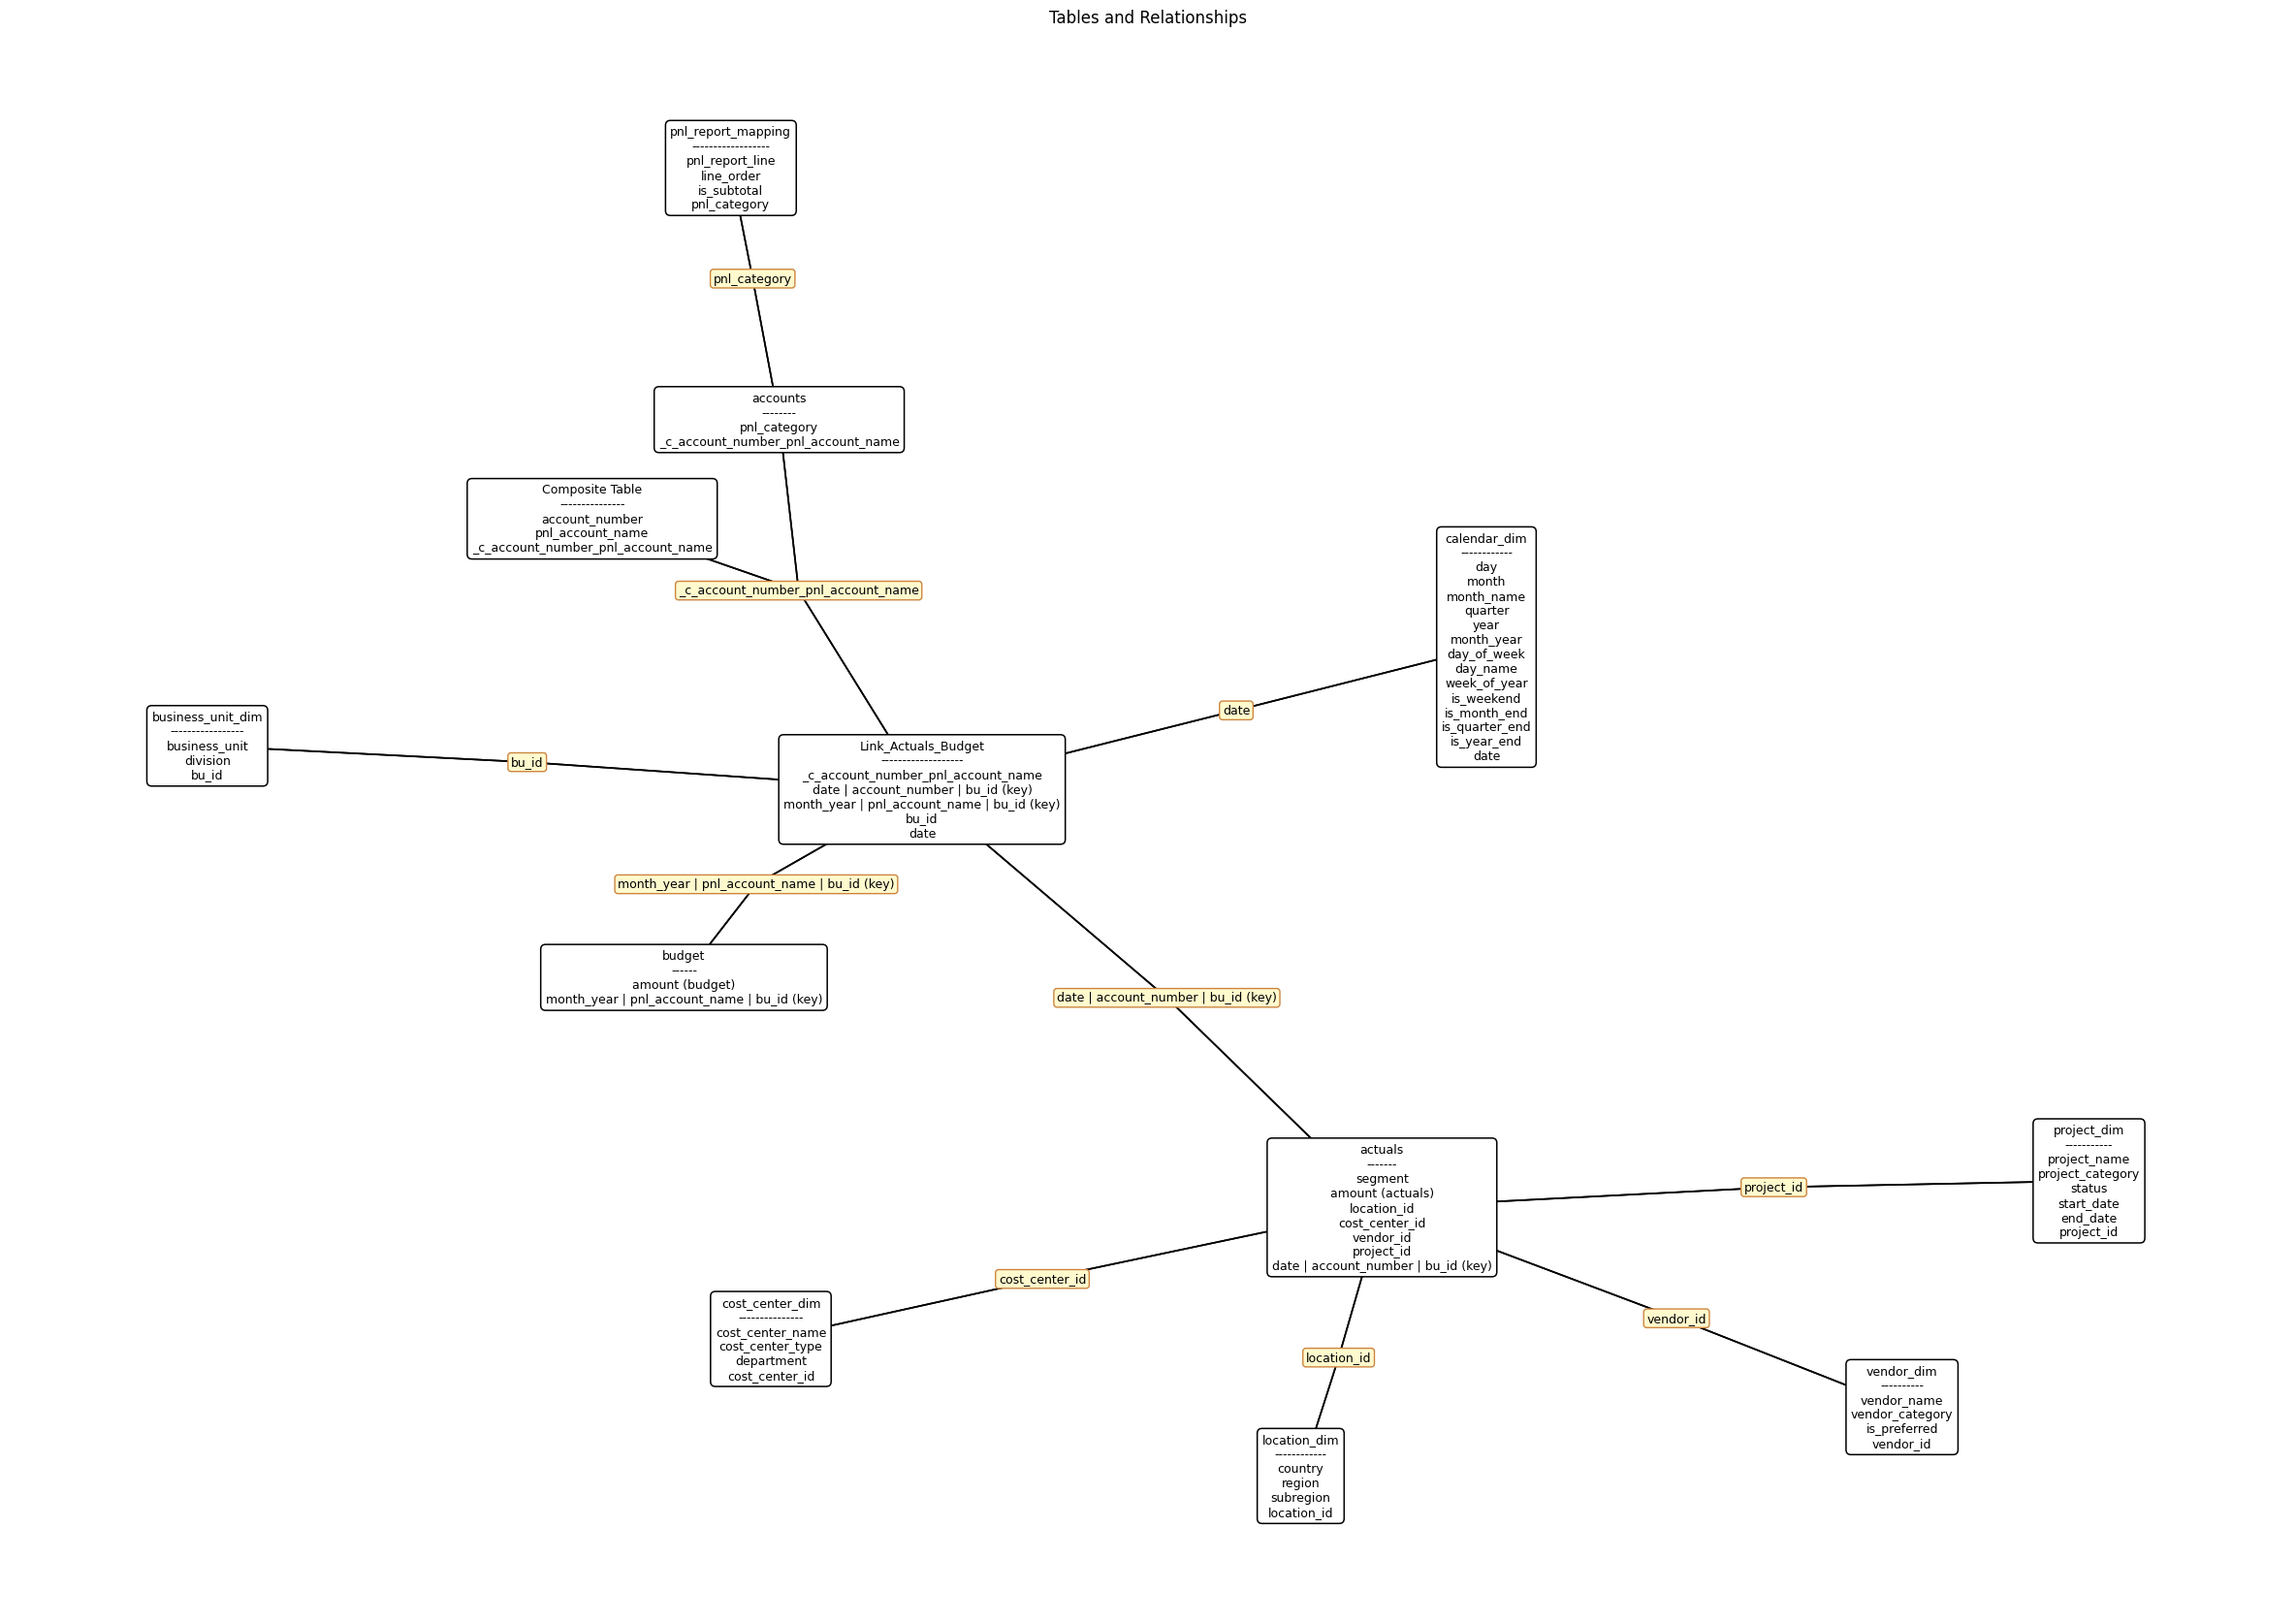

In [13]:
cube.visualize_graph(seed=21,full_column_names=False)